# Сравнение MLP, RNN и CNN для классификации изображений

В данной работе проводится сравнительный анализ различных архитектур нейронных сетей.
Цель исследования — определить влияние архитектуры модели на качество классификации изображений.

## Постановка задачи
Задача заключается в классификации медицинских изображений с использованием различных типов нейронных сетей.

В рамках работы рассматриваются три архитектуры:
- Полносвязная нейронная сеть (MLP)
- Рекуррентная нейронная сеть (RNN)
- Сверточная нейронная сеть (CNN)

Все модели обучаются и тестируются на одном и том же датасете, что позволяет провести корректное сравнение их эффективности.

## Датасет

В работе используется датасет Medical MNIST, содержащий медицинские изображения, разделённые на несколько классов.

Перед подачей в модель изображения проходят этап предобработки:
- изменение размера
- преобразование в тензоры
- нормализация

## Загрузка и предобработка данных

На данном этапе выполняется загрузка датасета и применение преобразований к изображениям.

In [ ]:
import torch
import torch.nn as nn
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

from models.mlp import MLP
from models.cnn import CNN
from models.rnn import RNN

from utils.train import train
from utils.evaluate import evaluate
from utils.dataset import get_dataloaders, get_class_names, get_dataset_info

def save_experiment(model, name, acc, losses):
    os.makedirs(f"experiments/{name}", exist_ok=True)
    os.makedirs("checkpoints", exist_ok=True)

    torch.save(model.state_dict(), f"checkpoints/{name}.pth")

    results = {
        "model": name,
        "accuracy": acc,
        "train_loss": losses
    }

    with open(f"experiments/{name}/results.json", "w") as f:
        json.dump(results, f, indent=4)

def run_experiment(model, name, train_loader, test_loader, epochs=5, lr=1e-3):

    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []

    for epoch in range(epochs):
        loss = train(model, train_loader, optimizer, criterion, device)
        train_losses.append(loss)

        print(f"{name} | Epoch {epoch+1}/{epochs} | Loss: {loss:.4f}")

    acc = evaluate(model, test_loader, device)

    save_experiment(model, name, acc, train_losses)

    return acc, train_losses

device = torch.device("mps" if torch.backends.mps.is_built() else "cpu")
torch.manual_seed(42)

data_dir = "data/Medical_MNIST"
dataset_info = get_dataset_info(data_dir)

print("Характеристики набора данных Medical MNIST:")
dataset_df = pd.DataFrame(dataset_info, index=[0]).T.rename(columns={0: "Value"})
display(dataset_df)

img_size = dataset_info["height"]
input_size = img_size * img_size
gray_scale = (dataset_info["channels"] == 1)

train_loader, test_loader = get_dataloaders(data_dir, batch_size=32, image_size=img_size, gray_scale=gray_scale)
classes = get_class_names(data_dir)

ru_map = {
    "AbdomenCT": "КТ брюшной полости",
    "BreastMRI": "МРТ молочной железы",
    "CXR": "Рентген грудной клетки",
    "ChestCT": "КТ грудной клетки",
    "Hand": "Рентген кисти",
    "HeadCT": "КТ головы"
}

classes_df = pd.DataFrame({
    "Class Name": classes,
    "Class Name (RU)": [ru_map[c] for c in classes]
}).rename(columns={0: "Class Index"})
print("Наименования классов:")
display(classes_df)

Характеристики набора данных Medical MNIST:


,Value
channels,1
height,64
width,64


Наименования классов:


,Class Name,Class Name (RU)
0,AbdomenCT,КТ брюшной полости
1,BreastMRI,МРТ молочной железы
2,CXR,Рентген грудной клетки
3,ChestCT,КТ грудной клетки
4,Hand,Рентген кисти
5,HeadCT,КТ головы


## Эксперимент 1: Полносвязная нейронная сеть (MLP)

Полносвязная нейронная сеть рассматривает изображение как одномерный вектор признаков.

Недостатком данного подхода является игнорирование пространственной структуры изображения.

In [2]:
mlp = MLP(input_size=input_size)
mlp_acc, mlp_loss = run_experiment(mlp, "MLP", train_loader, test_loader)

MLP | Epoch 1/5 | Loss: 0.0890
MLP | Epoch 2/5 | Loss: 0.0341
MLP | Epoch 3/5 | Loss: 0.0210
MLP | Epoch 4/5 | Loss: 0.0298
MLP | Epoch 5/5 | Loss: 0.0179


## Эксперимент 2: Рекуррентная нейронная сеть (RNN)

Для применения рекуррентной сети изображение преобразуется в последовательность (например, по строкам).

Данный подход позволяет использовать временные зависимости, однако не учитывает двумерную структуру изображения в полной мере.

In [3]:
rnn = RNN(input_size=img_size, hidden_size=img_size)
rnn_acc, rnn_loss = run_experiment(rnn, "RNN", train_loader, test_loader)

RNN | Epoch 1/5 | Loss: 0.1711
RNN | Epoch 2/5 | Loss: 0.0593
RNN | Epoch 3/5 | Loss: 0.0491
RNN | Epoch 4/5 | Loss: 0.0458
RNN | Epoch 5/5 | Loss: 0.0577


## Эксперимент 3: Сверточная нейронная сеть (CNN)

Сверточные нейронные сети специально разработаны для обработки изображений.

Они учитывают локальные пространственные зависимости и обладают свойством инвариантности к сдвигу.

In [4]:
cnn = CNN()
cnn_acc, cnn_loss = run_experiment(cnn, "CNN", train_loader, test_loader)

CNN | Epoch 1/5 | Loss: 0.2099
CNN | Epoch 2/5 | Loss: 0.0261
CNN | Epoch 3/5 | Loss: 0.0178
CNN | Epoch 4/5 | Loss: 0.0127
CNN | Epoch 5/5 | Loss: 0.0115


## Сравнение результатов

Результаты работы моделей представлены в таблице ниже.

In [9]:
def load_results(path):
    with open(path, "r") as f:
        return json.load(f)

results_dir = "experiments"
results_list = []

for model_name in os.listdir(results_dir):
    model_path = os.path.join(results_dir, model_name)

    if os.path.isdir(model_path):
        results_file = os.path.join(model_path, "results.json")

        if os.path.exists(results_file):
            data = load_results(results_file)
            results_list.append(data)

results_df = pd.DataFrame([
    {
        "Model": r["model"],
        "Accuracy": r["accuracy"],
        "Loss": r["train_loss"][-1]
    }
    for r in results_list
])

display(results_df)

,Model,Accuracy,Loss
0,CNN,0.996184,0.011536
1,RNN,0.986854,0.057728
2,MLP,0.994487,0.017869


## Визуализация результатов

Для анализа процесса обучения строятся графики изменения функции потерь и точности.

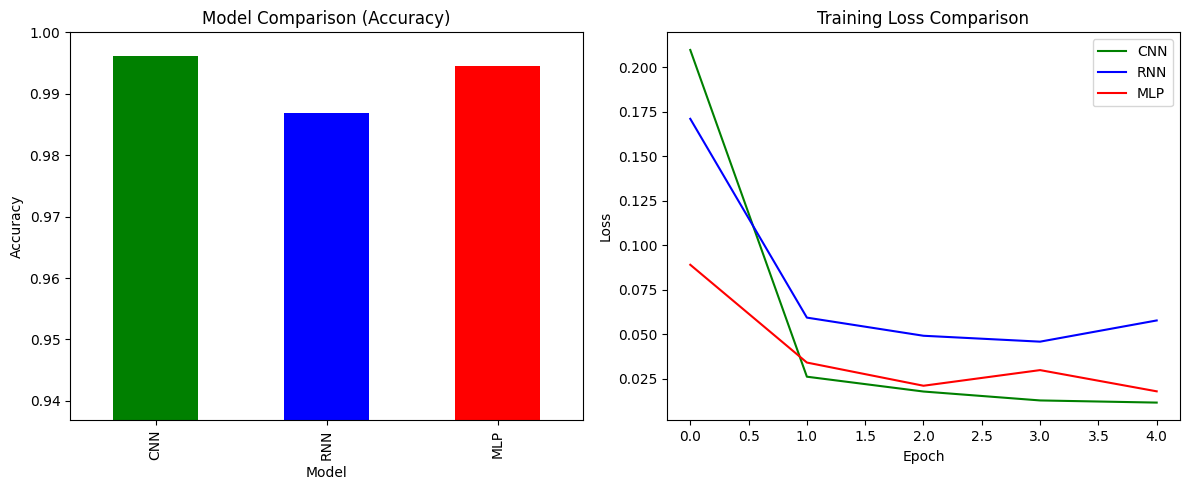

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
baseline = results_df["Accuracy"].min()
color_map = {
    "MLP": "red",
    "CNN": "green",
    "RNN": "blue"
}

colors = results_df["Model"].map(color_map)

results_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    ax=axes[0],
    color=colors
)

axes[0].set_title("Model Comparison (Accuracy)")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(baseline - 0.05, 1.0)

for r in results_list:
    axes[1].plot(r["train_loss"], label=r["model"], color = color_map[r["model"]])

axes[1].set_title("Training Loss Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## Вывод

В ходе работы было проведено сравнение различных архитектур нейронных сетей для задачи классификации изображений.

Полученные результаты показывают:

- Полносвязные сети демонстрируют наихудшие результаты, так как не учитывают структуру изображения.
- Рекуррентные сети показывают среднее качество, поскольку изображение не является естественной последовательностью.
- Сверточные нейронные сети достигают наилучших результатов благодаря учёту пространственных зависимостей.

Таким образом, выбор архитектуры нейронной сети должен соответствовать структуре входных данных.